# Advanced Task 8: Energy Consumption Forecasting

## Objective
Predict future household energy consumption based on historical time series data.

## Dataset
Household Power Consumption dataset containing daily electricity usage.

## Models Used
- ARIMA
- XGBoost (optional)

## Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [12]:
file_path = "dataset\power_consumption.csv"

df = pd.read_csv(file_path)

print("Columns in dataset:")
print(df.columns)

df.head()

Columns in dataset:
Index(['index', 'Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')


,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/2007,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/2007,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/2007,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/2007,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/2007,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [13]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# if dataset has date & time columns
if 'date' in df.columns and 'time' in df.columns:
    
    df['datetime'] = pd.to_datetime(
        df['date'] + " " + df['time'],
        dayfirst=True
    )

# if dataset already has datetime column
elif 'datetime' in df.columns:
    
    df['datetime'] = pd.to_datetime(df['datetime'])

else:
    raise ValueError("Dataset must contain date/time or datetime column")


# set index
df.set_index('datetime', inplace=True)

print(df.head())

                     index      date     time global_active_power  \
datetime                                                            
2007-01-01 00:00:00      0  1/1/2007  0:00:00                2.58   
2007-01-01 00:01:00      1  1/1/2007  0:01:00               2.552   
2007-01-01 00:02:00      2  1/1/2007  0:02:00                2.55   
2007-01-01 00:03:00      3  1/1/2007  0:03:00                2.55   
2007-01-01 00:04:00      4  1/1/2007  0:04:00               2.554   

                    global_reactive_power voltage global_intensity  \
datetime                                                             
2007-01-01 00:00:00                 0.136  241.97             10.6   
2007-01-01 00:01:00                   0.1  241.75             10.4   
2007-01-01 00:02:00                   0.1  241.64             10.4   
2007-01-01 00:03:00                   0.1  241.71             10.4   
2007-01-01 00:04:00                   0.1  241.98             10.4   

                    sub_m

In [14]:
# check power column
possible_names = [
    'global_active_power',
    'power',
    'consumption'
]

target_col = None

for col in possible_names:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("Power column not found")

print("Using column:", target_col)

Using column: global_active_power


In [17]:
# convert power column to numeric
df[target_col] = pd.to_numeric(
    df[target_col],
    errors='coerce'
)

# remove missing values
df = df.dropna(subset=[target_col])

print(df[target_col].dtype)

float64


In [18]:
df_hourly = df[target_col].resample('h').mean().dropna()

df_hourly.head()

datetime
2007-01-01 00:00:00    2.550633
2007-01-01 01:00:00    2.523400
2007-01-01 02:00:00    2.582333
2007-01-01 03:00:00    2.541667
2007-01-01 04:00:00    2.475733
Name: global_active_power, dtype: float64

In [19]:
data = df_hourly.to_frame(name='power')

data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)

data.head()

,power,hour,day_of_week,month,is_weekend
datetime,,,,,
2007-01-01 00:00:00,2.550633,0,0,1,0
2007-01-01 01:00:00,2.523400,1,0,1,0
2007-01-01 02:00:00,2.582333,2,0,1,0
2007-01-01 03:00:00,2.541667,3,0,1,0
2007-01-01 04:00:00,2.475733,4,0,1,0


In [20]:
train_size = int(len(data)*0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print(train.shape)
print(test.shape)

(3426, 5)
(857, 5)


In [21]:
arima_model = ARIMA(
    train['power'],
    order=(5,1,0)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

In [22]:
prophet_df = data.reset_index()

prophet_df = prophet_df.rename(
    columns={
        'datetime':'ds',
        'power':'y'
    }
)

prophet_train = prophet_df.iloc[:train_size]

prophet_model = Prophet()

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='h'
)

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].iloc[train_size:]

15:50:27 - cmdstanpy - INFO - Chain [1] start processing
15:50:28 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
features = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend'
]

X_train = train[features]
y_train = train['power']

X_test = test[features]
y_test = test['power']

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [24]:
def evaluate(true, pred, name):

    mae = mean_absolute_error(true, pred)

    rmse = np.sqrt(
        mean_squared_error(true, pred)
    )

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("------------------")


evaluate(test['power'], arima_pred, "ARIMA")

evaluate(test['power'], prophet_pred, "Prophet")

evaluate(test['power'], xgb_pred, "XGBoost")

ARIMA
MAE: 0.6024936625751365
RMSE: 0.9461800080042286
------------------
Prophet
MAE: 0.5758266978717053
RMSE: 0.7491487026501036
------------------
XGBoost
MAE: 0.5321834919191396
RMSE: 0.7341564939737187
------------------


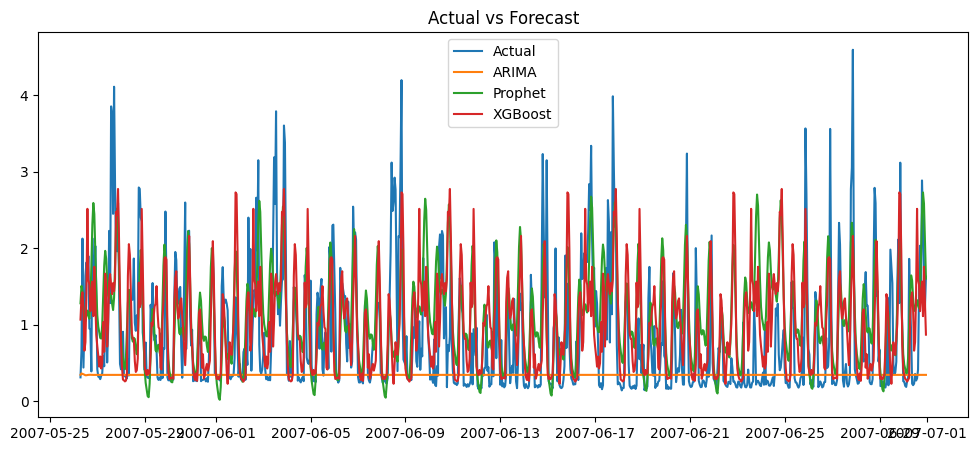

In [25]:
plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test['power'],
    label="Actual"
)

plt.plot(
    test.index,
    arima_pred,
    label="ARIMA"
)

plt.plot(
    test.index,
    prophet_pred,
    label="Prophet"
)

plt.plot(
    test.index,
    xgb_pred,
    label="XGBoost"
)

plt.legend()

plt.title("Actual vs Forecast")

plt.show()